In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

In [3]:
nav = pd.read_csv("../data/processed/nav_history_clean.csv")

fund_master = pd.read_csv("../data/processed/fund_master_clean.csv")

benchmark = pd.read_csv("../data/processed/benchmark_indices_clean.csv")

performance = pd.read_csv("../data/processed/scheme_performance_clean.csv")

In [4]:
nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [5]:
nav = nav.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [6]:
nav.head()

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [7]:
nav = nav.sort_values(["scheme_name", "date"])

nav["daily_return"] = (
    nav.groupby("scheme_name")["nav"].pct_change()
)

nav.head()

,amfi_code,date,nav,scheme_name,daily_return
3450,101206,2022-01-03,305.0996,ABSL Frontline Equity Fund - Regular - Growth,NaN
3451,101206,2022-01-04,305.4514,ABSL Frontline Equity Fund - Regular - Growth,0.001153
3452,101206,2022-01-05,306.6324,ABSL Frontline Equity Fund - Regular - Growth,0.003866
3453,101206,2022-01-06,305.9800,ABSL Frontline Equity Fund - Regular - Growth,-0.002128
3454,101206,2022-01-07,304.0480,ABSL Frontline Equity Fund - Regular - Growth,-0.006314


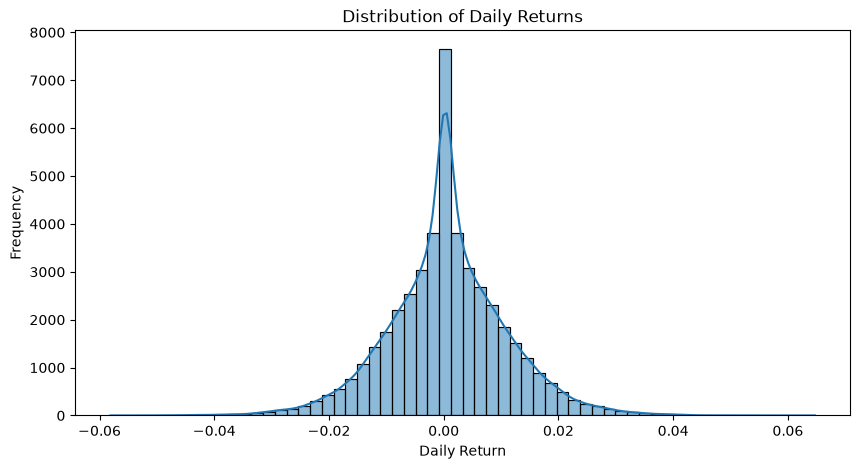

In [8]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=60,
    kde=True
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [9]:
def calculate_cagr(group, years):
    group = group.sort_values("date")

    end_date = group["date"].max()
    start_date = end_date - pd.DateOffset(years=years)

    period = group[group["date"] >= start_date]

    if len(period) < 2:
        return np.nan

    start_nav = period.iloc[0]["nav"]
    end_nav = period.iloc[-1]["nav"]

    cagr = ((end_nav / start_nav) ** (1 / years) - 1) * 100

    return cagr

In [10]:
cagr_results = []

for scheme, group in nav.groupby("scheme_name"):

    cagr_results.append({
        "scheme_name": scheme,
        "CAGR_1Y": calculate_cagr(group, 1),
        "CAGR_3Y": calculate_cagr(group, 3),
        "CAGR_5Y": calculate_cagr(group, 5)
    })

cagr_df = pd.DataFrame(cagr_results)

cagr_df.head()

,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,ABSL Frontline Equity Fund - Regular - Growth,47.924120,28.967695,20.442730
1,ABSL Liquid Fund - Regular - Growth,7.236645,6.315784,5.705734
2,ABSL Small Cap Fund - Regular - Growth,-23.986032,-4.152381,6.953336
3,Axis Bluechip Fund - Direct - Growth,19.766741,20.816771,6.917406
4,Axis Bluechip Fund - Regular - Growth,1.609119,0.525887,5.582555


In [11]:
cagr_df = cagr_df.sort_values(
    by="CAGR_5Y",
    ascending=False
)

cagr_df.head(10)

,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
18,ICICI Pru Midcap Fund - Regular - Growth,29.604659,31.777537,28.376762
36,SBI Small Cap Fund - Regular Plan - Growth,82.776059,26.669922,28.033224
8,DSP Small Cap Fund - Regular - Growth,65.138719,27.000427,27.917430
26,Mirae Asset Tax Saver Fund - Regular - Growth,39.751761,29.178902,27.629860
25,Mirae Asset Large Cap Fund - Regular - Growth,20.360678,34.000916,26.799277
22,Kotak Flexicap Fund - Regular - Growth,26.657082,29.582770,26.742494
11,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.232396,32.442459,26.074068
7,DSP Midcap Fund - Regular - Growth,21.481222,26.869991,25.611807
5,Axis Midcap Fund - Regular - Growth,22.261065,35.111802,24.445309
33,SBI Bluechip Fund - Regular Plan - Growth,60.437341,30.456524,22.384873


In [12]:
cagr_df.to_csv(
    "../reports/cagr_comparison.csv",
    index=False
)

print("CAGR comparison table saved successfully!")

CAGR comparison table saved successfully!


In [13]:
# Risk-free rate
risk_free_rate = 0.065

sharpe_results = []

for scheme, group in nav.groupby("scheme_name"):

    returns = group["daily_return"].dropna()

    # Skip funds with insufficient data
    if len(returns) < 2:
        continue

    # Annualized return
    annual_return = returns.mean() * 252

    # Annualized volatility
    annual_volatility = returns.std() * np.sqrt(252)

    # Sharpe Ratio
    sharpe = (annual_return - risk_free_rate) / annual_volatility

    sharpe_results.append({
        "scheme_name": scheme,
        "Annual Return": annual_return,
        "Annual Volatility": annual_volatility,
        "Sharpe Ratio": sharpe
    })

sharpe_df = pd.DataFrame(sharpe_results)

sharpe_df.head()

,scheme_name,Annual Return,Annual Volatility,Sharpe Ratio
0,ABSL Frontline Equity Fund - Regular - Growth,0.214647,0.145682,1.027213
1,ABSL Liquid Fund - Regular - Growth,0.060870,0.005064,-0.815567
2,ABSL Small Cap Fund - Regular - Growth,0.106962,0.257973,0.162661
3,Axis Bluechip Fund - Direct - Growth,0.083124,0.139833,0.129614
4,Axis Bluechip Fund - Regular - Growth,0.069295,0.139507,0.030785


In [14]:
sharpe_df = sharpe_df.sort_values(
    by="Sharpe Ratio",
    ascending=False
)

sharpe_df["Sharpe Rank"] = range(1, len(sharpe_df) + 1)

sharpe_df.head(10)

,scheme_name,Annual Return,Annual Volatility,Sharpe Ratio,Sharpe Rank
25,Mirae Asset Large Cap Fund - Regular - Growth,0.270566,0.141937,1.448291,1
22,Kotak Flexicap Fund - Regular - Growth,0.272602,0.158870,1.306744,2
26,Mirae Asset Tax Saver Fund - Regular - Growth,0.283262,0.176740,1.234930,3
33,SBI Bluechip Fund - Regular Plan - Growth,0.231033,0.137414,1.208267,4
18,ICICI Pru Midcap Fund - Regular - Growth,0.292653,0.192909,1.180101,5
7,DSP Midcap Fund - Regular - Growth,0.265908,0.177462,1.132122,6
11,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.272111,0.189367,1.093699,7
30,Nippon India Large Cap Fund - Regular - Growth,0.218037,0.141484,1.081659,8
0,ABSL Frontline Equity Fund - Regular - Growth,0.214647,0.145682,1.027213,9
15,ICICI Pru Bluechip Fund - Direct - Growth,0.212448,0.143638,1.026524,10


In [15]:
sharpe_df.to_csv(
    "../reports/sharpe_ratio.csv",
    index=False
)

print("Sharpe Ratio table saved successfully!")

Sharpe Ratio table saved successfully!


In [16]:
sortino_results = []

for scheme, group in nav.groupby("scheme_name"):

    returns = group["daily_return"].dropna()

    if len(returns) < 2:
        continue

    # Annualized return
    annual_return = returns.mean() * 252

    # Downside returns (negative returns only)
    downside_returns = returns[returns < 0]

    # Skip if no downside returns
    if len(downside_returns) < 2:
        continue

    # Downside deviation
    downside_std = downside_returns.std() * np.sqrt(252)

    # Sortino Ratio
    sortino = (annual_return - risk_free_rate) / downside_std

    sortino_results.append({
        "scheme_name": scheme,
        "Annual Return": annual_return,
        "Downside Volatility": downside_std,
        "Sortino Ratio": sortino
    })

sortino_df = pd.DataFrame(sortino_results)

sortino_df.head()

,scheme_name,Annual Return,Downside Volatility,Sortino Ratio
0,ABSL Frontline Equity Fund - Regular - Growth,0.214647,0.083157,1.799563
1,ABSL Liquid Fund - Regular - Growth,0.060870,0.002457,-1.681038
2,ABSL Small Cap Fund - Regular - Growth,0.106962,0.151683,0.276644
3,Axis Bluechip Fund - Direct - Growth,0.083124,0.081979,0.221087
4,Axis Bluechip Fund - Regular - Growth,0.069295,0.081689,0.052574


In [17]:
sortino_df = sortino_df.sort_values(
    by="Sortino Ratio",
    ascending=False
)

sortino_df["Sortino Rank"] = range(1, len(sortino_df) + 1)

sortino_df.head(10)

,scheme_name,Annual Return,Downside Volatility,Sortino Ratio,Sortino Rank
25,Mirae Asset Large Cap Fund - Regular - Growth,0.270566,0.086168,2.385644,1
22,Kotak Flexicap Fund - Regular - Growth,0.272602,0.087806,2.364320,2
26,Mirae Asset Tax Saver Fund - Regular - Growth,0.283262,0.101663,2.146914,3
33,SBI Bluechip Fund - Regular Plan - Growth,0.231033,0.077576,2.140267,4
18,ICICI Pru Midcap Fund - Regular - Growth,0.292653,0.112180,2.029353,5
7,DSP Midcap Fund - Regular - Growth,0.265908,0.107145,1.875101,6
30,Nippon India Large Cap Fund - Regular - Growth,0.218037,0.082717,1.850133,7
11,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.272111,0.113229,1.829134,8
15,ICICI Pru Bluechip Fund - Direct - Growth,0.212448,0.081675,1.805294,9
0,ABSL Frontline Equity Fund - Regular - Growth,0.214647,0.083157,1.799563,10


In [18]:
sortino_df.to_csv(
    "../reports/sortino_ratio.csv",
    index=False
)

print("Sortino Ratio table saved successfully!")

Sortino Ratio table saved successfully!


In [19]:
# Select Nifty 100 benchmark
nifty100 = benchmark[
    benchmark["index_name"].str.contains("Nifty 100", case=False, na=False)
].copy()

# Sort by date
nifty100 = nifty100.sort_values("date")

# Calculate benchmark daily returns
nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

# Keep only required columns
nifty100 = nifty100[["date", "benchmark_return"]]

nifty100.head()

,date,benchmark_return


In [20]:
alpha_beta_results = []

for scheme, group in nav.groupby("scheme_name"):

    # Merge fund returns with benchmark returns
    merged = group.merge(
        nifty100,
        on="date",
        how="inner"
    )

    merged = merged.dropna(subset=["daily_return", "benchmark_return"])

    # Skip if insufficient data
    if len(merged) < 30:
        continue

    regression = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    beta = regression.slope
    alpha = regression.intercept * 252

    alpha_beta_results.append({
        "scheme_name": scheme,
        "Alpha": alpha,
        "Beta": beta,
        "R_squared": regression.rvalue ** 2
    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)

alpha_beta_df.head()

""


In [41]:
nav[["scheme_name", "date", "daily_return"]].head()

,scheme_name,date,daily_return
3450,ABSL Frontline Equity Fund - Regular - Growth,2022-01-03,NaN
3451,ABSL Frontline Equity Fund - Regular - Growth,2022-01-04,0.001153
3452,ABSL Frontline Equity Fund - Regular - Growth,2022-01-05,0.003866
3453,ABSL Frontline Equity Fund - Regular - Growth,2022-01-06,-0.002128
3454,ABSL Frontline Equity Fund - Regular - Growth,2022-01-07,-0.006314


In [42]:
nifty100.head()

,date,benchmark_return


In [43]:
for scheme, group in nav.groupby("scheme_name"):

    merged = group.merge(
        nifty100,
        on="date",
        how="inner"
    )

    print(scheme, len(group), len(merged))

    break

ABSL Frontline Equity Fund - Regular - Growth 1150 0


In [44]:
for scheme, group in nav.groupby("scheme_name"):

    merged = group.merge(
        nifty100,
        on="date",
        how="inner"
    )

    print("Before:", len(merged))

    merged = merged.dropna(subset=["daily_return","benchmark_return"])

    print("After:", len(merged))

    break

Before: 0
After: 0


In [45]:
print(merged["daily_return"].isna().sum())
print(merged["benchmark_return"].isna().sum())

0
0


In [46]:
merged[["date", "daily_return", "benchmark_return"]].head(10)

,date,daily_return,benchmark_return


In [47]:
nifty100 = benchmark[
    benchmark["index_name"].str.contains("Nifty 100", case=False, na=False)
].copy()

nifty100 = nifty100.sort_values("date")
nifty100["benchmark_return"] = nifty100["close_value"].pct_change()
nifty100 = nifty100[["date", "benchmark_return"]]

In [48]:
benchmark["index_name"].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [49]:
print(nav["date"].dtype)
print(nifty100["date"].dtype)

print(nav["date"].head())
print(nifty100["date"].head())

datetime64[us]
datetime64[us]
3450   2022-01-03
3451   2022-01-04
3452   2022-01-05
3453   2022-01-06
3454   2022-01-07
Name: date, dtype: datetime64[us]
Series([], Name: date, dtype: datetime64[us])


In [50]:
nav["date"] = pd.to_datetime(nav["date"]).dt.normalize()
nifty100["date"] = pd.to_datetime(nifty100["date"]).dt.normalize()

In [51]:
for scheme, group in nav.groupby("scheme_name"):

    merged = group.merge(
        nifty100,
        on="date",
        how="inner"
    )

    print("Before:", len(merged))
    break

Before: 0


In [52]:
benchmark["index_name"].str.contains("Nifty 100", case=False)

0       False
1       False
2       False
3       False
4       False
        ...  
8045    False
8046    False
8047    False
8048    False
8049    False
Name: index_name, Length: 8050, dtype: bool

In [53]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

In [54]:
nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

nifty100 = nifty100[["date", "benchmark_return"]]

In [55]:
# Test whether NAV and Benchmark are merging correctly

for scheme, group in nav.groupby("scheme_name"):

    merged = group.merge(
        nifty100,
        on="date",
        how="inner"
    )

    print("Scheme:", scheme)
    print("Rows after merge:", len(merged))
    print(merged.head())

    break

Scheme: ABSL Frontline Equity Fund - Regular - Growth
Rows after merge: 1150
   amfi_code       date       nav  \
0     101206 2022-01-03  305.0996   
1     101206 2022-01-04  305.4514   
2     101206 2022-01-05  306.6324   
3     101206 2022-01-06  305.9800   
4     101206 2022-01-07  304.0480   

                                     scheme_name  daily_return  \
0  ABSL Frontline Equity Fund - Regular - Growth           NaN   
1  ABSL Frontline Equity Fund - Regular - Growth      0.001153   
2  ABSL Frontline Equity Fund - Regular - Growth      0.003866   
3  ABSL Frontline Equity Fund - Regular - Growth     -0.002128   
4  ABSL Frontline Equity Fund - Regular - Growth     -0.006314   

   benchmark_return  
0               NaN  
1         -0.013540  
2          0.004003  
3         -0.002935  
4          0.006150  


In [56]:
from scipy.stats import linregress

alpha_beta_results = []

for scheme, group in nav.groupby("scheme_name"):

    merged = group.merge(
        nifty100,
        on="date",
        how="inner"
    )

    merged = merged.dropna(subset=["daily_return", "benchmark_return"])

    if len(merged) < 30:
        continue

    regression = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha_beta_results.append({
        "scheme_name": scheme,
        "Alpha": regression.intercept * 252,
        "Beta": regression.slope,
        "R_squared": regression.rvalue ** 2
    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)

alpha_beta_df.head()

,scheme_name,Alpha,Beta,R_squared
0,ABSL Frontline Equity Fund - Regular - Growth,0.213998,0.021086,0.000348
1,ABSL Liquid Fund - Regular - Growth,0.060861,0.000267,0.000046
2,ABSL Small Cap Fund - Regular - Growth,0.108971,-0.065289,0.001064
3,Axis Bluechip Fund - Direct - Growth,0.082328,0.025883,0.000569
4,Axis Bluechip Fund - Regular - Growth,0.068995,0.009731,0.000081


In [57]:
print(alpha_beta_df.shape)

(40, 4)


In [58]:
alpha_beta_df = alpha_beta_df.sort_values(
    by="Alpha",
    ascending=False
)

alpha_beta_df.head(10)

,scheme_name,Alpha,Beta,R_squared
36,SBI Small Cap Fund - Regular Plan - Growth,0.303370,-0.023196,1.414258e-04
8,DSP Small Cap Fund - Regular - Growth,0.300579,0.011455,3.532991e-05
18,ICICI Pru Midcap Fund - Regular - Growth,0.292636,0.000549,1.345534e-07
26,Mirae Asset Tax Saver Fund - Regular - Growth,0.282704,0.018134,1.748889e-04
22,Kotak Flexicap Fund - Regular - Growth,0.273305,-0.022830,3.430543e-04
11,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.271954,0.005104,1.206652e-05
25,Mirae Asset Large Cap Fund - Regular - Growth,0.269838,0.023684,4.625437e-04
7,DSP Midcap Fund - Regular - Growth,0.265986,-0.002523,3.357978e-06
5,Axis Midcap Fund - Regular - Growth,0.260767,-0.066265,1.936879e-03
33,SBI Bluechip Fund - Regular Plan - Growth,0.232010,-0.031751,8.869789e-04


In [59]:
alpha_beta_df.to_csv("../reports/alpha_beta.csv", index=False)

In [60]:
mdd_results = []

for scheme, group in nav.groupby("scheme_name"):

    group = group.sort_values("date").copy()

    # Running maximum NAV
    group["running_max"] = group["nav"].cummax()

    # Drawdown
    group["drawdown"] = (group["nav"] / group["running_max"]) - 1

    # Maximum drawdown
    max_dd = group["drawdown"].min()

    # Date of worst drawdown
    worst_date = group.loc[group["drawdown"].idxmin(), "date"]

    mdd_results.append({
        "scheme_name": scheme,
        "Maximum_Drawdown": max_dd,
        "Worst_Date": worst_date
    })

mdd_df = pd.DataFrame(mdd_results)

mdd_df = mdd_df.sort_values(
    by="Maximum_Drawdown"
)

mdd_df.head(10)

,scheme_name,Maximum_Drawdown,Worst_Date
35,SBI Small Cap Fund - Direct Plan - Growth,-0.525742,2025-10-28
6,Axis Small Cap Fund - Regular - Growth,-0.516778,2026-05-11
2,ABSL Small Cap Fund - Regular - Growth,-0.354469,2026-05-11
8,DSP Small Cap Fund - Regular - Growth,-0.311719,2025-01-03
36,SBI Small Cap Fund - Regular Plan - Growth,-0.287060,2025-05-14
38,UTI Mid Cap Fund - Regular - Growth,-0.280011,2026-04-27
14,HDFC Top 100 Fund - Regular Plan - Growth,-0.247344,2022-09-15
21,Kotak Emerging Equity Fund - Regular - Growth,-0.240035,2024-10-17
31,Nippon India Small Cap Fund - Regular - Growth,-0.233449,2026-02-20
3,Axis Bluechip Fund - Direct - Growth,-0.217514,2023-05-22


In [61]:
mdd_df.to_csv("../reports/maximum_drawdown.csv", index=False)

mdd_df.head()

,scheme_name,Maximum_Drawdown,Worst_Date
35,SBI Small Cap Fund - Direct Plan - Growth,-0.525742,2025-10-28
6,Axis Small Cap Fund - Regular - Growth,-0.516778,2026-05-11
2,ABSL Small Cap Fund - Regular - Growth,-0.354469,2026-05-11
8,DSP Small Cap Fund - Regular - Growth,-0.311719,2025-01-03
36,SBI Small Cap Fund - Regular Plan - Growth,-0.287060,2025-05-14


In [75]:
# Get expense ratio from scheme_performance
expense = performance[["scheme_name", "expense_ratio_pct"]]

# Merge all metrics into one scorecard
scorecard = (
    cagr_df.merge(sharpe_df, on="scheme_name")
           .merge(alpha_beta_df[["scheme_name", "Alpha"]], on="scheme_name")
           .merge(mdd_df[["scheme_name", "Maximum_Drawdown"]], on="scheme_name")
           .merge(expense, on="scheme_name", how="left")
)

# Create ranks
scorecard["return_rank"] = scorecard["CAGR_3Y"].rank(ascending=False)
scorecard["sharpe_rank"] = scorecard["Sharpe Ratio"].rank(ascending=False)
scorecard["alpha_rank"] = scorecard["Alpha"].rank(ascending=False)
scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(ascending=True)
scorecard["mdd_rank"] = scorecard["Maximum_Drawdown"].rank(ascending=False)

# Composite Fund Score
scorecard["Fund_Score"] = (
    0.30 * scorecard["return_rank"] +
    0.25 * scorecard["sharpe_rank"] +
    0.20 * scorecard["alpha_rank"] +
    0.15 * scorecard["expense_rank"] +
    0.10 * scorecard["mdd_rank"]
)

# Convert to a 0-100 score
scorecard["Score_100"] = (
    100 * (scorecard["Fund_Score"].max() - scorecard["Fund_Score"])
    / (scorecard["Fund_Score"].max() - scorecard["Fund_Score"].min())
)

# Sort by highest score
scorecard = scorecard.sort_values(
    by="Score_100",
    ascending=False
)

# Display top 10
scorecard.head(10)

,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y,Annual Return,Annual Volatility,Sharpe Ratio,Sharpe Rank,Alpha,Maximum_Drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,mdd_rank,Fund_Score,Score_100
4,Mirae Asset Large Cap Fund - Regular - Growth,20.360678,34.000916,26.799277,0.270566,0.141937,1.448291,1,0.269838,-0.112657,1.46,2.0,1.0,7.0,23.0,8.0,6.500,100.000000
0,ICICI Pru Midcap Fund - Regular - Growth,29.604659,31.777537,28.376762,0.292653,0.192909,1.180101,5,0.292636,-0.181885,1.36,5.0,5.0,3.0,15.0,25.0,8.100,94.439618
5,Kotak Flexicap Fund - Regular - Growth,26.657082,29.582770,26.742494,0.272602,0.158870,1.306744,2,0.273305,-0.129740,1.45,7.0,2.0,5.0,22.0,13.0,8.200,94.092094
6,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.232396,32.442459,26.074068,0.272111,0.189367,1.093699,7,0.271954,-0.162172,1.38,4.0,7.0,6.0,17.0,20.0,8.700,92.354474
12,ICICI Pru Bluechip Fund - Direct - Growth,13.064279,32.487429,20.234028,0.212448,0.143638,1.026524,10,0.211948,-0.125883,0.80,3.0,10.0,13.0,12.0,12.0,9.000,91.311903
8,Axis Midcap Fund - Regular - Growth,22.261065,35.111802,24.445309,0.258728,0.194071,0.998231,11,0.260767,-0.209609,1.38,1.0,11.0,9.0,17.0,28.0,10.200,87.141616
9,SBI Bluechip Fund - Regular Plan - Growth,60.437341,30.456524,22.384873,0.231033,0.137414,1.208267,4,0.232010,-0.150124,1.54,6.0,4.0,10.0,30.5,17.0,11.075,84.100782
3,Mirae Asset Tax Saver Fund - Regular - Growth,39.751761,29.178902,27.629860,0.283262,0.176740,1.234930,3,0.282704,-0.163967,1.60,8.0,3.0,4.0,36.5,21.0,11.525,82.536924
11,ABSL Frontline Equity Fund - Regular - Growth,47.924120,28.967695,20.442730,0.214647,0.145682,1.027213,9,0.213998,-0.112916,1.60,9.0,9.0,12.0,36.5,9.0,13.725,74.891399
1,SBI Small Cap Fund - Regular Plan - Growth,82.776059,26.669922,28.033224,0.302656,0.251406,0.945308,14,0.303370,-0.287060,1.43,12.0,14.0,1.0,21.0,36.0,14.050,73.761946


In [76]:
scorecard.to_csv("../reports/fund_scorecard.csv", index=False)

print("Fund Scorecard updated successfully!")

Fund Scorecard updated successfully!


In [67]:
# Top 5 funds based on scorecard

top5_funds = scorecard.head(5)["scheme_name"].tolist()

print(top5_funds)

['Mirae Asset Large Cap Fund - Regular - Growth', 'Kotak Flexicap Fund - Regular - Growth', 'ICICI Pru Midcap Fund - Regular - Growth', 'HDFC Mid-Cap Opportunities Fund - Regular - Growth', 'Mirae Asset Tax Saver Fund - Regular - Growth']


In [68]:
import pandas as pd

# Last available date
end_date = nav["date"].max()

# Three years back
start_date = end_date - pd.DateOffset(years=3)

# Filter NAV
top5_nav = nav[
    (nav["scheme_name"].isin(top5_funds)) &
    (nav["date"] >= start_date)
].copy()

top5_nav.head()

,amfi_code,date,nav,scheme_name,daily_return
2665,100033,2023-05-29,147.2155,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.004216
2666,100033,2023-05-30,147.2007,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.000101
2667,100033,2023-05-31,147.4640,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.001789
2668,100033,2023-06-01,146.5954,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.005890
2669,100033,2023-06-02,145.8015,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.005416


In [69]:
# Keep only NIFTY50 and NIFTY100

benchmark_3yr = benchmark[
    (benchmark["index_name"].isin(["NIFTY50", "NIFTY100"])) &
    (benchmark["date"] >= start_date)
].copy()

benchmark_3yr.head()

,date,index_name,close_value
365,2023-05-29,NIFTY50,24688.69
366,2023-05-30,NIFTY50,24558.17
367,2023-05-31,NIFTY50,24476.07
368,2023-06-01,NIFTY50,24375.89
369,2023-06-02,NIFTY50,24398.93


In [70]:
# Normalize Top 5 fund NAVs

top5_nav["normalized_nav"] = (
    top5_nav.groupby("scheme_name")["nav"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

# Normalize Benchmarks

benchmark_3yr["normalized_index"] = (
    benchmark_3yr.groupby("index_name")["close_value"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

top5_nav.head()

,amfi_code,date,nav,scheme_name,daily_return,normalized_nav
2665,100033,2023-05-29,147.2155,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.004216,100.000000
2666,100033,2023-05-30,147.2007,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.000101,99.989947
2667,100033,2023-05-31,147.4640,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.001789,100.168800
2668,100033,2023-06-01,146.5954,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.005890,99.578781
2669,100033,2023-06-02,145.8015,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.005416,99.039503


In [71]:
import plotly.express as px
import pandas as pd

# Fund data
fund_plot = top5_nav[["date", "scheme_name", "normalized_nav"]].rename(
    columns={
        "scheme_name": "Series",
        "normalized_nav": "Value"
    }
)

# Benchmark data
benchmark_plot = benchmark_3yr[["date", "index_name", "normalized_index"]].rename(
    columns={
        "index_name": "Series",
        "normalized_index": "Value"
    }
)

# Combine
plot_df = pd.concat([fund_plot, benchmark_plot], ignore_index=True)

# Plot
fig = px.line(
    plot_df,
    x="date",
    y="Value",
    color="Series",
    title="Top 5 Mutual Funds vs NIFTY50 & NIFTY100 (Normalized to 100)"
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Normalized Value (Base = 100)",
    legend_title="Fund / Benchmark"
)

fig.show()

# Save chart
fig.write_image("../charts/benchmark_comparison.png")

In [72]:
tracking_results = []

for fund in top5_funds:

    fund_df = top5_nav[top5_nav["scheme_name"] == fund][
        ["date", "daily_return"]
    ]

    bench_df = nifty100.copy()

    merged = fund_df.merge(
        bench_df,
        on="date",
        how="inner"
    ).dropna()

    tracking_error = (
        (merged["daily_return"] - merged["benchmark_return"]).std()
        * (252 ** 0.5)
    )

    tracking_results.append({
        "scheme_name": fund,
        "Tracking_Error": tracking_error
    })

tracking_df = pd.DataFrame(tracking_results)

tracking_df = tracking_df.sort_values(
    "Tracking_Error"
)

tracking_df

,scheme_name,Tracking_Error
0,Mirae Asset Large Cap Fund - Regular - Growth,0.187867
1,Kotak Flexicap Fund - Regular - Growth,0.206410
4,Mirae Asset Tax Saver Fund - Regular - Growth,0.216924
3,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.224838
2,ICICI Pru Midcap Fund - Regular - Growth,0.232515


In [73]:
tracking_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

print("Tracking Error saved successfully.")

Tracking Error saved successfully.
